In [1]:
from bagpy import bagreader
file_name = '../../../metrics_m600_ipp_tro_2023-12-15-09-51-46_2024-06-28-16-55-10.bag'
b = bagreader(file_name)
b.topic_table

[INFO]  Data folder ../../../metrics_m600_ipp_tro_2023-12-15-09-51-46_2024-06-28-16-55-10 already exists. Not creating.


,Topics,Types,Message Count,Frequency
0,/uav1/odometry,nav_msgs/Odometry,75288,119837.257143
1,/uav1/planner/plan_request,planner_map_interfaces/PlanRequest,1,NaN
2,/uav1/realtime_search/average_entropy,std_msgs/Float32,1708,1.999993
3,/uav1/realtime_search/average_prob,std_msgs/Float32,1707,1.999997


In [2]:
import pandas as pd
entropy_csv = b.message_by_topic('/uav1/realtime_search/average_entropy')
entropy_df = pd.read_csv(entropy_csv)
entropy_df["time-normalized"] = entropy_df["Time"] - entropy_df["Time"][0]
entropy_df = entropy_df.drop("Time", axis=1)
entropy_df.set_index("time-normalized", inplace=True)
entropy_df

,data
time-normalized,
0.000000,0.033239
0.499706,0.032757
0.999727,0.032642
1.499719,0.032613
1.999753,0.032601
...,...
851.499915,0.003306
851.999831,0.003306
852.499833,0.003306


In [3]:
entropy_df["data"] = entropy_df["data"]/entropy_df["data"].max() * 100

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(font_scale=1.5, style="white")

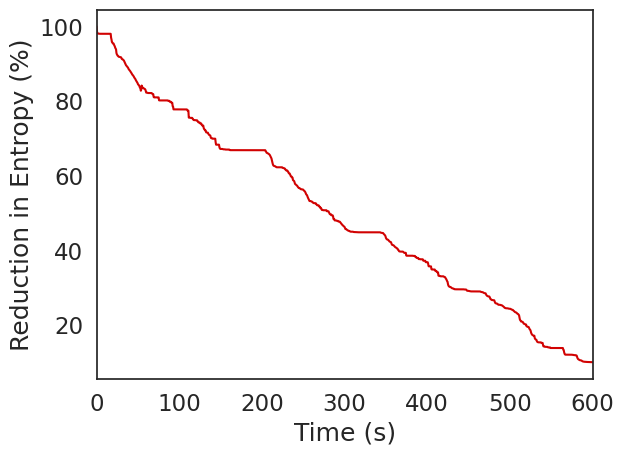

In [14]:
# plt.title("Entropy over time")
# plt.ylim(0, 0.035)
plt.ylabel("Reduction in Entropy (%)")
plt.xlabel("Time (s)")
plt.xlim(0, 600)
g = sns.lineplot(entropy_df["data"], color="#d10202")

In [15]:
g.get_figure().savefig("field_test_entropy_over_time.png", bbox_inches="tight" )

In [16]:
odom_csv = b.message_by_topic('/uav1/odometry')
odom_df = pd.read_csv(odom_csv)
odom_df["time-normalized"] = odom_df["Time"] - odom_df["Time"][0]
odom_df["time-normalized"]
odom_df = odom_df.drop("Time", axis=1)
odom_df.set_index("time-normalized", inplace=True)
odom_df["pose.pose.position.z"]

time-normalized
0.000000      50.174866
0.000212      50.174866
0.000245      50.173935
0.000343      50.173935
0.025652      50.173935
                ...    
770.752355    58.894958
770.752365    58.894958
770.752795    58.894958
770.796821    58.894958
770.840342    58.894958
Name: pose.pose.position.z, Length: 75288, dtype: float64

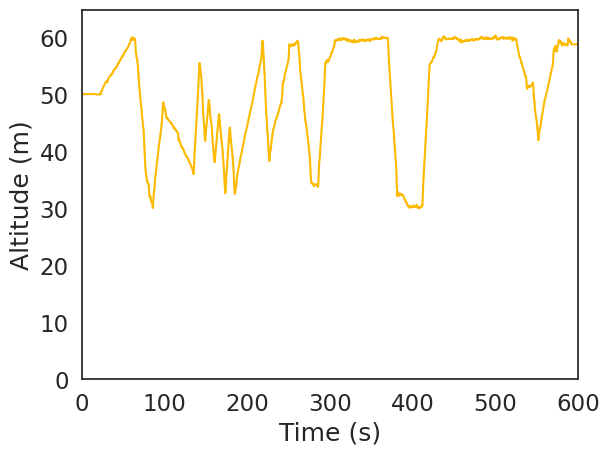

In [17]:
plt.ylim(00, 65)
# plt.title("Altitude over time")
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.xlim(0, 600)
g = sns.lineplot(odom_df["pose.pose.position.z"], color="#fcba03")

In [18]:
g.get_figure().savefig("field_test_altitude_over_time.png", bbox_inches="tight" )